# Connecting D-SheetPiling to the probabilistic library 

## Introduction

This tutorial demonstrates how to connect a **D-SheetPiling** model to the **probabilistic library** to perform a **FORM** (First Order Reliability Method) analysis. The connection is made through the [D-GEOLib](https://deltares.github.io/GEOLib/) Python library, which provides a programmatic interface to D-SheetPiling.

The workflow consists of three steps:

1. **Build (or load) a D-SheetPiling model** using D-GEOLib (tested with version 2.8.0)
2. **Wrap it in a Python function** that the probabilistic library can call as a limit state function
3. **Parametrize** the stochastic variables.
4. **Run the FORM analysis** and interpret the results
5. **Inspect** and post-process the results

### Problem description

We consider a **cantilever sheet pile wall** along a canal in a two-layer soil profile:

- **Sand** (top layer, 0.0 to −5.0 m NAP) — a medium-dense sand whose strength is governed by its friction angle $\phi$
- **Clay** (bottom layer, −5.0 m NAP and below) — a soft clay whose strength is governed by its undrained shear strength $S_u$

The wall retains ground on the left side (ground level at 0.0 m NAP) against the canal on the right side (canal bed at −5.0 m NAP, canal water level at −2.0 m NAP). A phreatic surface is present behind the wall on the retained side.

The **limit state function** compares the maximum bending moment computed by D-SheetPiling against the moment capacity of the sheet pile section:

$$g = M_{\text{capacity}} - |M_{\text{max,calculated}}|$$

Failure occurs when $g \leq 0$ (the calculated moment exceeds the section capacity).

### Stochastic variables

| Variable | Description | Unit | Distribution | Mean | CoV |
|----------|-------------|------|-------------|------|-----|
| `phi_sand` | Friction angle of the sand layer | ° | Normal | 25 | 0.10 |
| `su_clay` | Undrained shear strength of the clay layer | kPa | Log-normal | 20 | 0.10 |
| `phreatic_level` | Phreatic level behind the wall (retained side) | m NAP | Uniform | [−4.0, −2.0] | — |

<img src="../tutorials/Dsheetpiling_model.png" alt="" width="900"/>


First, let's import the necessary packages to run this example. You need a Python environment with the GEOLIB library (
pip install d-geolib) installed to make run the following cells.


In [127]:
from geolib.models.dsheetpiling import DSheetPilingModel
from geolib.models.dsheetpiling.constructions import Sheet, SheetPileProperties
from geolib.models.dsheetpiling.dsheetpiling_model import SheetModelType
from geolib.models.dsheetpiling.profiles import SoilProfile, SoilLayer
from geolib.models.dsheetpiling.settings import (
    LateralEarthPressureMethod,
    LateralEarthPressureMethodStage,
    Side,
    PassiveSide,
)
from geolib.models.dsheetpiling.water_level import WaterLevel
from geolib.geometry.one import Point
from geolib.soils import Soil
from geolib.models.dsheetpiling.surface import Surface

from probabilistic_library import ReliabilityProject, DistributionType, ReliabilityMethod, StandardNormal

import copy
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import tempfile

## Step 1 — Build the D-SheetPiling base model (optional)

We first create a deterministic D-SheetPiling model that represents the **mean** (baseline) configuration. This model will be modified at each iteration of the FORM algorithm, substituting the stochastic parameter values provided by the probabilsitic library.

> **Tip:** If you already have a `.shi` file, you can load it directly with `model.parse("path/to/file.shi")` instead of building it from scratch and fast-forward to step 2.

### 1.1 — Create the model and set the calculation method

In [128]:
base_model = DSheetPilingModel()

console_path = Path(r"C:\Program Files (x86)\Deltares\D-Sheet Piling 24.1.1\DSheetPiling.exe")
base_model.set_meta_property("dsheetpiling_console_path", console_path)

# Use the KA-KO-KP earth pressure method for sheet piling
base_model.set_model(SheetModelType(method=LateralEarthPressureMethod.C_PHI_DELTA))
base_model.datastructure.input_data.model.check_vertical_balance = False

### 1.2 — Define the soils

We define two soil layers:
- **Sand** — a frictional material (φ = 30°, c = 0)
- **Clay** — a cohesive material modelled with undrained shear strength (φ = 0°, c = S_u = 25 kPa)

These properties are overwritten at each FORM iteration with the stochastic parameter values defined in the model.

In [129]:
# Sand layer (frictional)
sand = Soil(name="Sand")
sand.soil_weight_parameters.saturated_weight = 20.0        # saturated unit weight [kN/m³]
sand.soil_weight_parameters.unsaturated_weight = 17.0        # dry unit weight [kN/m³]
sand.mohr_coulomb_parameters.friction_angle = 25.0           # friction angle [°] will be overwritten in the limit state function to introduce uncertainty
sand.mohr_coulomb_parameters.cohesion = 0.0       # cohesion [kPa]
sand.mohr_coulomb_parameters.friction_angle_interface = 20.0         # wall friction angle [°]
base_model.add_soil(sand)

# Clay layer (cohesive, undrained)
clay = Soil(name="Clay")
clay.soil_weight_parameters.saturated_weight = 18.0        # saturated unit weight [kN/m³]
clay.soil_weight_parameters.unsaturated_weight = 16.0        # dry unit weight [kN/m³]
clay.mohr_coulomb_parameters.friction_angle = 0.0            # friction angle [°] (undrained: φ = 0)
clay.mohr_coulomb_parameters.cohesion = 20.0      # undrained shear strength Su [kPa] will be overwritten in the limit state function to introduce uncertainty
clay.mohr_coulomb_parameters.friction_angle_interface = 0.0          # wall friction angle [°]
base_model.add_soil(clay)

'Clay'

### 1.3 — Define the sheet pile construction

We place a sheet pile wall with its top at **0.0 m NAP** and a bottom at **−35.0 m NAP**. The section has an elastic stiffness EI = 50 000 kNm²/m and a characteristic elastic moment capacity of **M_capacity = 500 kNm/m**.

In [130]:
# Moment capacity of the sheet pile section [kNm/m]
M_CAPACITY = 500.0

sheet = Sheet(
    name="AZ 26",
    sheet_pile_properties=SheetPileProperties(
        elastic_stiffness_ei=50000,          # EI [kNm²/m]
        section_bottom_level=-35.0,          # bottom of the sheet pile [m NAP]
        mr_char_el=M_CAPACITY,               # characteristic elastic moment capacity [kNm/m]
    ),
)
base_model.set_construction(top_level=0.0, elements=[sheet])

### 1.4 — Define the construction stage

A single construction stage with:
- **Left (retained) side:** ground level at 0.0 m NAP, Sand from 0.0 to −5.0 m, Clay below −5.0 m. Phreatic level at −1.0 m NAP.
- **Right (canal) side:** canal bed at −5.0 m NAP, Clay below −5.0 m. Canal water level at −2.0 m NAP.

In [131]:
# Add a construction stage
stage_id = base_model.add_stage(
    name="Canal",
    passive_side=PassiveSide.DSHEETPILING_DETERMINED,
    method_left=LateralEarthPressureMethodStage.C_PHI_DELTA,
    method_right=LateralEarthPressureMethodStage.C_PHI_DELTA,
)

# Add a new surface object at the retained side
surface_left = Surface(name="Surface_left", points=[Point(x=0.0, z=0.0)])
base_model.add_surface(surface_left, side=Side.LEFT, stage_id=stage_id)

# Left side (retained): Sand 0.0 to -5.0 m, Clay below -5.0 m
profile_left = SoilProfile(
    name="Left",
    layers=[
        SoilLayer(top_of_layer=0.0, soil="Sand"),
        SoilLayer(top_of_layer=-5.0, soil="Clay"),
    ],
    coordinate=Point(x=0.0),
)
base_model.add_profile(profile_left, side=Side.LEFT, stage_id=stage_id)

# Phreatic level behind the wall (retained side) at -1.0 m NAP
wl_left = WaterLevel(name="WL_left", level=-1.0)
base_model.add_head_line(wl_left, side=Side.LEFT, stage_id=stage_id)

bottom_depth = -5.0

# Add a new surface object at the canal side
surface_right = Surface(name="Surface_right", points=[Point(x=0.0, z=bottom_depth)])
base_model.add_surface(surface_right, side=Side.RIGHT, stage_id=stage_id)

profile_right = SoilProfile(
    name="Right",
    layers=[
        SoilLayer(top_of_layer=bottom_depth, soil="Clay"),
    ],
    coordinate=Point(x=0.0, z=bottom_depth),
)
base_model.add_profile(profile_right, side=Side.RIGHT, stage_id=stage_id)

# Canal water level
wl_right = WaterLevel(name="WL_right", level=-2.0)
base_model.add_head_line(wl_right, side=Side.RIGHT, stage_id=stage_id)

### Alternative: Loading an existing `.shi` file

If you already have a D-SheetPiling input file, the setup simplifies to:

```python
base_model = DSheetPilingModel()
base_model.parse(Path("path/to/your_model.shi"))
```

The rest of the workflow (defining the wrapper function, setting up the reliability project, running FORM) remains identical. The only thing that changes is *how* you update the stochastic parameters inside the limit state function — you need to locate the correct soil or water level object in the parsed data structure.

## Step 2 — Define the limit state function

The limit state function is a regular Python function whose **argument names** must match the variable names used in the project object of the probabilistic library. At each FORM iteration the probabilistic library calls this function with a new set of parameter values.

Inside the function we:
1. **Deep-copy** the base model so the original is not modified
2. **Update** the stochastic parameters (soil properties, phreatic level)
3. **Serialize** the model to a `.shi` file and **Execute** D-SheetPiling
4. **Extract** the maximum bending moment from the output
5. **Return** $g = M_{\text{capacity}} - |M_{\text{max}}|$

In [132]:
i = 1

In [133]:
# Working directory for temporary .shi files
WORK_DIR = Path(tempfile.mkdtemp(prefix="dsheet_ptk_")).resolve()

def lsf_sheetpile(phi_sand, su_clay, phreatic_level):
    """
    Limit state function: g = M_capacity - |M_max|

    Parameters
    ----------
    phi_sand : float
        Friction angle of the sand layer [°].
    su_clay : float
        Undrained shear strength of the clay layer [kPa].
    phreatic_level : float
        Phreatic level behind the wall (retained side) [m NAP].
    """
    global i
    
    # 1. Deep-copy the base model
    model = copy.deepcopy(base_model)

    # Add a safeguard against too low strength values, they could make DSheet-piling crash and we consider them as failed anyway.
    if phi_sand <= 5.0 or su_clay <= 5.0:
        return 0

    # 2. Update stochastic soil parameters
    #    Soil[0] = Sand, Soil[1] = Clay (order follows add_soil calls)
    soils = model.datastructure.input_data.soil_collection.soil

    # Sand: update friction angle and wall friction (δ = 2/3 × φ)
    soils[0].soilphi = phi_sand
    soils[0].soildelta = 2 / 3 * phi_sand

    # Clay: update undrained shear strength (entered as cohesion with φ = 0)
    soils[1].soilcohesion = su_clay

    #. Update the phreatic level on the retained side
    model.datastructure.input_data.waterlevels.levels[0].level = phreatic_level

    # 3. Serialize and execute
    shi_path = WORK_DIR / f"model_{i}.shi"
    i += 1

    model.serialize(shi_path)
    model.execute()

    # 4. Extract maximum bending moment from the output
    stage_output = model.output.construction_stage[0]
    mfd = stage_output.moments_forces_displacements.momentsforcesdisplacements
    max_moment = max(abs(row["moment"]) for row in mfd)

    # 5. Return the limit state value
    g = M_CAPACITY - max_moment

    return g

### Key points about the wrapper function

- The function signature `lsf_sheetpile(phi_sand, su_clay, phreatic_level)` defines the **stochastic variables**. The probabilistic library uses introspection on the function arguments to automatically register them.
- Each call to the function creates a **fresh copy** of the base model (`copy.deepcopy`), updates the relevant parameters, and runs D-SheetPiling. This ensures that each FORM iteration is independent.
- The soil objects in `model.datastructure.input_data.soil_collection.soil` are indexed in the order they were added: `soil[0]` = Sand, `soil[1]` = Clay.
- The function must return a **scalar** value: the limit state value $g$. The sign convention is $g > 0$ (safe) and $g \leq 0$ (failure).
- D-SheetPiling must be installed on the machine and accessible via the default console path (or set `model.custom_console_path`).

## Step 3 — Set up the Reliability Project

We create a `ReliabilityProject`, assign the limit state function as the model, and define the stochastic variables with their distributions.

In [134]:
project = ReliabilityProject()
project.model = lsf_sheetpile

### Define the stochastic variables

Each argument of `lsf_sheetpile` is automatically available as a variable in `project.variables`. We specify the marginal distribution, mean, and either the coefficient of variation (`variation`) or the standard deviation (`deviation`).

Note that `su_clay` uses a **log-normal** distribution, which is common for undrained shear strength as it is strictly positive and typically right-skewed. The `phreatic_level` uses a **uniform** distribution to represent the range of groundwater levels behind the wall.

In [135]:
# Friction angle of sand: Normal(mean=25°, CoV=0.10)
project.variables["phi_sand"].distribution = DistributionType.normal
project.variables["phi_sand"].mean = 25.0
project.variables["phi_sand"].variation = 0.10

# Undrained shear strength of clay: Log-normal(mean=20 kPa, CoV=0.10)
project.variables["su_clay"].distribution = DistributionType.log_normal
project.variables["su_clay"].mean = 20.0
project.variables["su_clay"].variation = 0.10

# Phreatic level behind the wall: Uniform(lower=-4.0, upper=-2.0)
project.variables["phreatic_level"].distribution = DistributionType.uniform
project.variables["phreatic_level"].minimum = -4.0
project.variables["phreatic_level"].maximum = -2.0

## Step 4 — Run the FORM analysis

We configure the FORM settings and run the analysis. The `relaxation_factor` controls the step size in the algorithm; a smaller value improves stability for models with a non-smooth response surface but makes convergence slower. The convergence threshold can also be modified the parameter `epsilon_beta`.

For more details about the FORM procedure, please refer to the [scientific documentation](https://github.com/Deltares/ProbabilisticLibrary/releases/download/26.2.1/scientific_background.pdf).

In [136]:
project.settings.reliability_method = ReliabilityMethod.form

project.settings.maximum_iterations = 80
project.settings.relaxation_factor = 0.15 
project.settings.step_size = 0.05  # Step size for finite difference approximation of the reliability index gradient
project.settings.epsilon_beta = 0.05  # This is the convergence criterion for the reliability index β (stop if |β_new - β_old| < ε_β)

# Save intermediate results for plotting
project.settings.save_convergence = True
project.settings.save_realizations = True

project.run()

Added 2 lines to run_identification.
Added 2 lines to run_identification.
Added 2 lines to run_identification.
Added 2 lines to run_identification.
Added 2 lines to run_identification.
Added 2 lines to run_identification.
Added 2 lines to run_identification.
Added 2 lines to run_identification.
Added 2 lines to run_identification.
Added 2 lines to run_identification.
Added 2 lines to run_identification.
Added 2 lines to run_identification.
Added 2 lines to run_identification.
Added 2 lines to run_identification.
Added 2 lines to run_identification.
Added 2 lines to run_identification.
Added 2 lines to run_identification.
Added 2 lines to run_identification.
Added 2 lines to run_identification.
Added 2 lines to run_identification.
Added 2 lines to run_identification.
Added 2 lines to run_identification.
Added 2 lines to run_identification.
Added 2 lines to run_identification.
Added 2 lines to run_identification.
Added 2 lines to run_identification.
Added 2 lines to run_identification.
A

## Step 5 — Read the results

After the FORM analysis converges, the design point contains:
- **β** — the reliability index
- **P_f** — the probability of failure
- **α-factors** — the influence coefficients showing each variable's contribution
- **Design-point values** — the parameter values at the most likely failure point

In [137]:
project.design_point.print()

Reliability (FORM)
 Reliability index = 1.876
 Probability of failure = 0.0303
 Convergence = 0.04096 (converged)
 Model runs = 80
Alpha values:
 phi_sand: alpha = 0.2015, x = 24.05
 su_clay: alpha = 0.9114, x = 16.78
 phreatic_level: alpha = -0.3589, x = -2.501



> **Tip:** The D-Sheetpiling files are saved for every iteration (model_i.shi and model_i.shd) which allows for further control. They can be found in the folder defined as WORK_DIR. It is important to manually check if the values for the stochastic parameters have been correctly written in the file and are physically possible (no negative friction angle for example).

## Step 6 — Visualise the results

### 6.1 — FORM convergence

The convergence plot shows the reliability index $\beta$ and the convergence criterion as a function of the FORM iteration number. A stable, converging $\beta$ confirms that the algorithm has found a consistent design point.

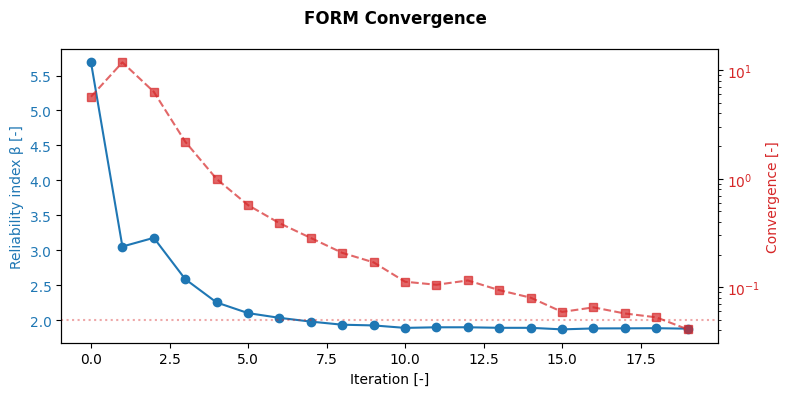

In [138]:
iterations = [r.index for r in dp.reliability_results]
betas = [r.reliability_index for r in dp.reliability_results]
convergences = [r.convergence for r in dp.reliability_results]

fig, ax1 = plt.subplots(figsize=(8, 4))

color_beta = "tab:blue"
ax1.set_xlabel("Iteration [-]")
ax1.set_ylabel("Reliability index β [-]", color=color_beta)
ax1.plot(iterations, betas, "o-", color=color_beta, label="β")
ax1.tick_params(axis="y", labelcolor=color_beta)

ax2 = ax1.twinx()
color_conv = "tab:red"
ax2.set_ylabel("Convergence [-]", color=color_conv)
ax2.plot(iterations, convergences, "s--", color=color_conv, alpha=0.7, label="convergence")
ax2.axhline(project.settings.variation_coefficient, color=color_conv, linestyle=":", alpha=0.4, label="threshold")
ax2.tick_params(axis="y", labelcolor=color_conv)
ax2.set_yscale("log")

fig.suptitle("FORM Convergence", fontweight="bold")
fig.tight_layout()
plt.show()

### 6.2 — Design point in the variable domain

The scatter plot below shows all model evaluations performed during the FORM iterations, projected onto the two most influential variables. The **design point** (black marker) is the most probable failure point. Red points indicate failure ($g \leq 0$), green points indicate safe evaluations ($g > 0$).

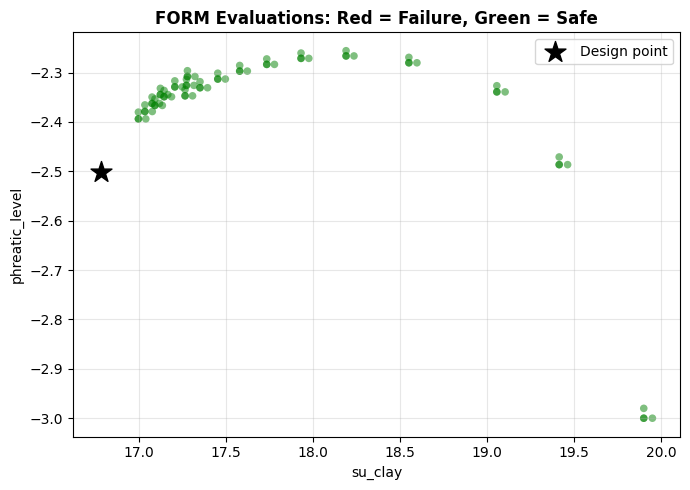

In [139]:
# Identify the two most influential variables
influence = [alpha.influence_factor for alpha in dp.alphas]
idx_sorted = np.argsort(influence)
idx_x, idx_y = int(idx_sorted[-1]), int(idx_sorted[-2])

# Extract realization values
x_vals = [r.input_values[idx_x] for r in dp.realizations]
y_vals = [r.input_values[idx_y] for r in dp.realizations]
z_vals = [r.z for r in dp.realizations]
colors = ["red" if z <= 0 else "green" for z in z_vals]

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(x_vals, y_vals, c=colors, alpha=0.5, edgecolors="none", s=30)
ax.scatter(
    dp.alphas[idx_x].x,
    dp.alphas[idx_y].x,
    marker="*", s=250, c="black", zorder=5, label="Design point",
)
ax.set_xlabel(dp.alphas[idx_x].identifier)
ax.set_ylabel(dp.alphas[idx_y].identifier)
ax.legend()
ax.set_title("FORM Evaluations: Red = Failure, Green = Safe", fontweight="bold")
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

### 6.3 — Influence factors (pie chart)

The influence factor of each variable equals $\alpha^2$; all influence factors sum to 1. The pie chart shows at a glance which uncertain parameters dominate the failure probability and where further investigation or risk reduction measures would be most effective.

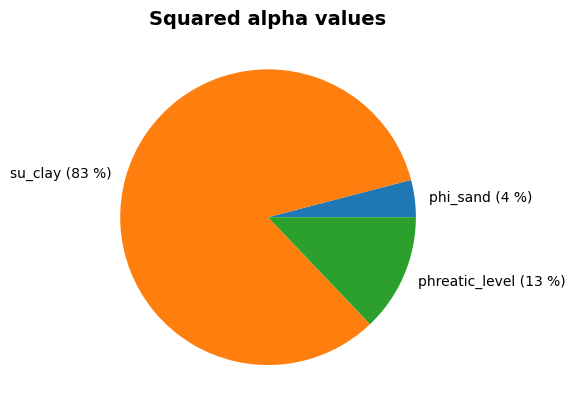

In [140]:
project.design_point.plot_alphas()

## Interpretation

The **α-factors** indicate the relative importance of each variable in driving the failure probability:

- A large |α| for `phi_sand` means the sand friction angle dominates the uncertainty — investing in better soil investigation of the sand layer would be the most effective way to reduce uncertainty.
- A large |α| for `su_clay` indicates that the clay strength is a critical parameter. This is expected for configurations where the sheet pile toe is embedded in clay below the canal bed.
- A large |α| for `phreatic_level` suggests that the groundwater level behind the wall relative to the canal water level is an important driver. Controlling seepage or drainage on the retained side would reduce uncertainty.
- The sign of α indicates the direction: a **positive** α means the variable contributes to resistance (increasing it makes the structure safer), while a **negative** α means it contributes to loading.

The **design-point values** $x^*$ represent the most probable combination of parameter values that leads to failure. These can be compared to the characteristic or design values used in semi-probabilistic codes (e.g., Eurocode 7) as a consistency check.

Credits: Thanks to Antonis Mavritsakis (Deltares)